In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer

In [3]:
from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator

## Importing the dataset (CIFAR)

In [4]:
from darnax.datasets.classification.cifar10 import Cifar10

data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2566685366, 2716172981], dtype=uint32)

In [5]:
# In order to do something:
# first we take a batch of data and we standardize it

x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


In [6]:
def compute_cosine_similarity_matrix(states_history, layer_idx=1, batch_idx=None):
    
    n_timesteps = len(states_history)
    sim_matrix = np.zeros((n_timesteps, n_timesteps))
    
    # Only compute upper triangle (cosine similarity is symmetric)
    for i in range(n_timesteps):
        for j in range(i, n_timesteps):
            state_i = states_history[i].states[layer_idx]
            state_j = states_history[j].states[layer_idx]
            
            # Flatten both states to (batch, features)
            s_i = state_i.reshape(state_i.shape[0], -1)
            s_j = state_j.reshape(state_j.shape[0], -1)
            
            if batch_idx is not None:
                # Single image: cosine similarity for that image
                sim = cosine_similarity([s_i[batch_idx]], [s_j[batch_idx]])[0, 0]
                sim_matrix[i, j] = sim
                sim_matrix[j, i] = sim
            else:
                # All images: compute similarity for each, then average
                sim_list = []
                for b in range(s_i.shape[0]):
                    try:
                        sim = cosine_similarity([s_i[b]], [s_j[b]])[0, 0]
                        sim_list.append(sim)
                    except:
                        sim_list.append(np.nan)
                
                sim_value = np.nanmean(sim_list)
                sim_matrix[i, j] = sim_value
                sim_matrix[j, i] = sim_value
    
    return sim_matrix

## Build model

In [8]:
N_CHANNELS = 64
INPUT_KERNEL_SIZE = 7
RECUR_KERNEL_SIZE = 7

key = jax.random.PRNGKey(0)
key, model_keys = jax.random.split(key)
keys_net = jax.random.split(model_keys, 5)

input_to_hidden = Conv2D(
    in_channels=3,
    out_channels=N_CHANNELS,
    kernel_size=INPUT_KERNEL_SIZE,
    threshold=1.7,
    strength=1.0,
    key=keys_net[0],
    padding_mode='constant', 
)

recurrent_conv = Conv2DRecurrentDiscrete(
    channels=N_CHANNELS,
    kernel_size=RECUR_KERNEL_SIZE,
    groups=N_CHANNELS,
    j_d=0.9,
    threshold=1.7,
    padding_mode="constant",
    key=keys_net[1],
    lr = 1.0, 
    weight_decay= 0.0
)

pooling_forward = GlobalMajorityPooling(
    strength=1.0,
    axis=(1, 2)
)

unpooling_backward = GlobalUnpooling(
    strength=1.0,
    axis=(1, 2)
)

recurrent = RecurrentDiscrete(
    features=N_CHANNELS,
    j_d=0.9,
    threshold=1.7,
    key=keys_net[2],
)

wout = FullyConnected(
    in_features=N_CHANNELS,
    out_features=10,
    strength=1.0,
    threshold=1.7,
    key=keys_net[3],
)

wback = FrozenRescaledFullyConnected(
    in_features=10,
    out_features=N_CHANNELS,
    strength=1.0,
    threshold=0.0,
    key=keys_net[4],
)

## Layermap

In [9]:
from darnax.layer_maps.sparse import LayerMap

layer_map_dict = {

    # what speaks TO the first layer
    1: {
        0: input_to_hidden, # the input
        1: recurrent_conv, # itself through a recurrent convolution
        2: unpooling_backward, # the unpooling from the fully connected
    },

    # what speaks to the fully connected layer
    2: {
        1: pooling_forward, # the pooling from the convolutional layer
        2: recurrent, # itself through a recurrent connection
        3: wback, # the feedback from the output
    },

    # who speaks to the output
    3: {
        2: wout, # the output from the fully connected layer
        3: OutputLayer(), # the output layer itself, its just a placeholder
    }
}

layer_map = LayerMap.from_dict(layer_map_dict)

## State

In [10]:
from darnax.states.sequential import SequentialState

state = SequentialState(
    [
        (32, 32, 3), # the input shape
        (32, 32, N_CHANNELS), # the convolutional layer shape
        (N_CHANNELS,), # the fully connected layer shape
        (10,) # the output shape
    ]
)

## Orchestrator

In [11]:
from darnax.orchestrators.sequential import SequentialOrchestrator

orchestrator = SequentialOrchestrator(
    layers=layer_map,
)

## Dynamics 

In [ ]:
# then we can do a forward pass

key, forward_key = jax.random.split(key)

# this does a single step of the dynamics, it does not compute messages coming from labels
# it can be seen as the warmup 
state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")
#state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")

for _ in range(5):
    # this does the same, but computes all messages (clamped phase)
    state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="all")


for _ in range(5):
    # free phase
    state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")

## The Update Step — closing the learning loop

Everything above is **dynamics only**: we ran warmup → clamped → free and got a final state. But the weights never changed. Now we add the **learning step** — the part that actually modifies the parameters.

### What happens conceptually

After the free phase, the network has settled to a fixed point $s^*$. The learning rule asks: *for each neuron $i$, is this fixed point stable enough?* It measures the **stability margin**:

$$m_i = s_i^* \cdot h_i$$

where $h_i$ is the local field (the pre-activation sum of all inputs to neuron $i$). If $m_i \leq \kappa$ (the threshold), the neuron is "marginally stable" and its incoming weights get a Hebbian update $\Delta J_{ij} \propto s_i^* \cdot s_j^*$.

### What we need to call (and from where)

The update has **3 steps**, each using a different piece of the library:

**Step 1: `orchestrator.backward(state, rng)`** — from [orchestrators/sequential.py](../src/darnax/orchestrators/sequential.py)
- Walks every edge `(i, j)` in the LayerMap
- For each module, calls `module.backward(x=state[j], y=state[i], y_hat=aggregated[i])`
- Each module internally uses `perceptron_rule_backward` (from [utils/perceptron_rule.py](../src/darnax/utils/perceptron_rule.py)) — the margin-based Hebbian rule
- Returns an **orchestrator-shaped PyTree of updates** (ΔW for each module), NOT new parameters

**Step 2: `optimizer.update(grads, opt_state)`** — from `optax`
- Takes the raw updates and scales them by the per-module learning rates
- Returns scaled updates + new optimizer state

**Step 3: `eqx.apply_updates(orchestrator, updates)`** — from `equinox`
- Adds the scaled updates to the current parameters: `param_new = param_old + update`
- Returns a new orchestrator with updated weights

In [12]:
import equinox as eqx
import jax.numpy as jnp
import jax.tree_util as jtu
import optax

# ============================================================
# STEP 0: Re-initialize everything cleanly (state + rng)
# ============================================================
# We need a fresh state for this batch, just like DynamicalTrainer._train_step_impl does.
state_for_update = SequentialState(
    [(32, 32, 3), (32, 32, N_CHANNELS), (N_CHANNELS,), (10,)]
)
state_for_update = state_for_update.init(x, y)  # sets input buffer to x, output buffer to y

key, update_key = jax.random.split(key)

# ============================================================
# STEP 0b: Run the 3-phase dynamics (warmup → clamped → free)
# ============================================================
# Same as the cell above, but on our fresh state.

# Warmup: only forward messages (input → hidden). Labels are NOT injected.
for _ in range(1):
    state_for_update, update_key = orchestrator.step(
        state_for_update, rng=update_key, filter_messages="forward"
    )

# Clamped: ALL messages flow, including feedback from labels (output → hidden).
# This is the "transient supervision" that nudges the attractor toward the correct class.
for _ in range(5):
    state_for_update, update_key = orchestrator.step(
        state_for_update, rng=update_key, filter_messages="all"
    )

# Free: supervision removed again. Only forward+recurrent messages.
# The network relaxes to a nearby fixed point s* — hopefully close to the supervised one.
for _ in range(5):
    state_for_update, update_key = orchestrator.step(
        state_for_update, rng=update_key, filter_messages="inference"
    )

print("Dynamics done. Now computing updates...")

# ============================================================
# STEP 1: orchestrator.backward(state, rng)
#   Source: src/darnax/orchestrators/sequential.py  →  SequentialOrchestrator.backward()
#
#   What it does:
#   - For every edge (i, j) in the LayerMap, it calls module.backward(x, y, y_hat)
#   - Each module uses perceptron_rule_backward (margin-based Hebbian rule)
#   - Returns an orchestrator-shaped PyTree of UPDATES (same structure, but leaves are ΔW, ΔJ, etc.)
# ============================================================
grads = orchestrator.backward(state_for_update, rng=update_key)

# Let's inspect what we got — grads has the same tree structure as orchestrator,
# but each leaf is an update tensor (mostly zeros for frozen modules)
print("\nGrads tree structure (same as orchestrator):")
print(jax.tree.map(lambda x: x.shape if hasattr(x, 'shape') else type(x), grads))

# ============================================================
# STEP 2: Set up an optax optimizer and apply the learning rates
#   Source: optax library (external)
#
#   What it does:
#   - We use optax.multi_transform to assign different learning rates
#     to different modules (conv kernel, recurrent J, W_out, etc.)
#   - "default" lr=0 means frozen modules (pooling, unpooling, wback, OutputLayer)
#     get zero updates even if backward returned something nonzero
# ============================================================

# First, build a label tree: every parameter leaf gets a string label
# that tells optax which learning rate group it belongs to.
params, _ = eqx.partition(orchestrator, eqx.is_inexact_array)

# Start with everything labeled "default" (lr=0, i.e. frozen)
labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

# Helper to broadcast a label string to all leaves of a subtree
def like(tree, value: str):
    return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

# Now override specific modules with their own learning rate labels:
#   (1, 0) = input_to_hidden (Conv2D)         → label "w_in"
#   (1, 1) = recurrent_conv (Conv2DRecurrent)  → label "j_conv"
#   (2, 2) = recurrent FC (RecurrentDiscrete)  → label "j_fc"
#   (3, 2) = wout (FullyConnected)             → label "w_out"
overrides = {
    (1, 0): "w_in",      # conv input adapter
    (1, 1): "j_conv",    # conv recurrent kernel
    (2, 2): "j_fc",      # FC recurrent J
    (3, 2): "w_out",     # output weights
}

for (i, j), label in overrides.items():
    labels = eqx.tree_at(
        lambda m, _i=i, _j=j: m.lmap[_i][_j],
        labels,
        replace=like(params.lmap[i][j], label),
    )

# Define learning rates for each group
LR_WIN   = 0.1    # input conv adapter
LR_JCONV = 0.05   # conv recurrent kernel
LR_JFC   = 0.05   # FC recurrent J
LR_WOUT  = 0.1    # output weights

optimizer = optax.multi_transform(
    {
        "default": optax.sgd(learning_rate=0.0),   # frozen: no update
        "w_in":    optax.sgd(learning_rate=LR_WIN),
        "j_conv":  optax.sgd(learning_rate=LR_JCONV),
        "j_fc":    optax.sgd(learning_rate=LR_JFC),
        "w_out":   optax.sgd(learning_rate=LR_WOUT),
    },
    labels,
)

# Initialize the optimizer state (needed for optax bookkeeping)
opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))

# Now apply the optimizer: it scales the raw grads by the learning rates
# and returns the scaled updates + new optimizer state.
grads_filtered = eqx.filter(grads, eqx.is_inexact_array)
params_filtered = eqx.filter(orchestrator, eqx.is_inexact_array)
updates, opt_state = optimizer.update(grads_filtered, opt_state, params=params_filtered)

# ============================================================
# STEP 3: eqx.apply_updates(orchestrator, updates)
#   Source: equinox library
#
#   What it does:
#   - For each leaf: new_param = old_param + update
#   - Returns a NEW orchestrator (functional, no mutation)
# ============================================================
orchestrator_after = eqx.apply_updates(orchestrator, updates)

# ============================================================
# Verify something changed
# ============================================================
old_wout = orchestrator.lmap[3][2].W
new_wout = orchestrator_after.lmap[3][2].W
diff_wout = jnp.abs(new_wout - old_wout).mean()

old_j_fc = orchestrator.lmap[2][2].J
new_j_fc = orchestrator_after.lmap[2][2].J
diff_j_fc = jnp.abs(new_j_fc - old_j_fc).mean()

old_conv_kernel = orchestrator.lmap[1][1].kernel
new_conv_kernel = orchestrator_after.lmap[1][1].kernel
diff_conv = jnp.abs(new_conv_kernel - old_conv_kernel).mean()

print(f"\n✓ Update applied successfully!")
print(f"  Mean |ΔW_out|  = {diff_wout:.6f}")
print(f"  Mean |ΔJ_fc|   = {diff_j_fc:.6f}")
print(f"  Mean |ΔK_conv| = {diff_conv:.6f}")

# Now orchestrator_after has the updated weights. 
# Use it for the next batch: orchestrator = orchestrator_after

Dynamics done. Now computing updates...

Grads tree structure (same as orchestrator):
SequentialOrchestrator(
  lmap=LayerMap(
    _data={
      1:
      {
        0:
        Conv2D(
          kernel=(7, 7, 3, 64),
          threshold=(),
          lr=(),
          weight_decay=(),
          strength=1.0,
          in_channels=3,
          out_channels=64,
          stride=(1, 1),
          kernel_size=(7, 7),
          padding_mode='constant'
        ),
        1:
        Conv2DRecurrentDiscrete(
          kernel=(7, 7, 1, 64),
          threshold=(),
          j_d=(),
          lr=(),
          weight_decay=(),
          update_mask=(7, 7, 1, 64),
          channels=64,
          groups=64,
          kernel_size=(7, 7),
          padding_mode='constant',
          central_element=(3, 3)
        ),
        2: GlobalUnpooling(strength=(), axis=(1, 2))
      },
      2:
      {
        1: GlobalMajorityPooling(strength=(), axis=(1, 2)),
        2:
        RecurrentDiscrete(
          J=

## Single-batch analysis — a few updates with trajectory tracking

We apply a small number of weight updates (1–3) to a **single batch** and record the full dynamics trajectory after each update. This lets us see how even a handful of Hebbian updates change the attractor landscape, without waiting for a full training loop.

For a proper accuracy evaluation over the whole dataset, see the **Fast training loop** section below (using `DynamicalTrainer` with JIT compilation).

In [15]:
def run_dynamics_with_history(orchestrator, x, y, rng, n_warmup=1, n_clamped=5, n_free=5):
    """Run 3-phase dynamics on one batch and return the trajectory.
    
    Returns:
        final_state: the state after all phases
        rng: updated rng key  
        trajectory: list of SequentialState snapshots (one per step)
    """
    state = SequentialState([(32, 32, 3), (32, 32, N_CHANNELS), (N_CHANNELS,), (10,)])
    state = state.init(x, y)
    trajectory = []
    
    for _ in range(n_warmup):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="forward")
        trajectory.append(state)
    
    for _ in range(n_clamped):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="all")
        trajectory.append(state)
    
    for _ in range(n_free):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        trajectory.append(state)
    
    return state, rng, trajectory

In [16]:
# ============================================================
# Single-batch analysis: N_UPDATES on ONE batch
# ============================================================
N_UPDATES = 3
N_WARMUP = 1
N_CLAMPED = 5
N_FREE = 5

LR_WIN   = 0.1
LR_JCONV = 0.05
LR_JFC   = 0.05
LR_WOUT  = 0.1

# ---- Rebuild a fresh model (reproducible from seed 0) ----
key = jax.random.PRNGKey(0)
key, model_keys = jax.random.split(key)
keys_net = jax.random.split(model_keys, 5)

_input_to_hidden = Conv2D(
    in_channels=3, out_channels=N_CHANNELS, kernel_size=INPUT_KERNEL_SIZE,
    threshold=1.7, strength=1.0, key=keys_net[0], padding_mode='constant',
)
_recurrent_conv = Conv2DRecurrentDiscrete(
    channels=N_CHANNELS, kernel_size=RECUR_KERNEL_SIZE, groups=N_CHANNELS,
    j_d=0.9, threshold=1.7, padding_mode="constant",
    key=keys_net[1], lr=1.0, weight_decay=0.0,
)
_pooling_forward = GlobalMajorityPooling(strength=1.0, axis=(1, 2))
_unpooling_backward = GlobalUnpooling(strength=1.0, axis=(1, 2))
_recurrent = RecurrentDiscrete(
    features=N_CHANNELS, j_d=0.9, threshold=1.7, key=keys_net[2],
)
_wout = FullyConnected(
    in_features=N_CHANNELS, out_features=10,
    strength=1.0, threshold=1.7, key=keys_net[3],
)
_wback = FrozenRescaledFullyConnected(
    in_features=10, out_features=N_CHANNELS,
    strength=1.0, threshold=0.0, key=keys_net[4],
)

_layer_map = LayerMap.from_dict({
    1: {0: _input_to_hidden, 1: _recurrent_conv, 2: _unpooling_backward},
    2: {1: _pooling_forward, 2: _recurrent, 3: _wback},
    3: {2: _wout, 3: OutputLayer()},
})
orch = SequentialOrchestrator(layers=_layer_map)

# ---- Build optimizer (same per-module learning rates) ----
params, _ = eqx.partition(orch, eqx.is_inexact_array)
labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

def like(tree, value):
    return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

for (i, j), label in {(1,0): "w_in", (1,1): "j_conv", (2,2): "j_fc", (3,2): "w_out"}.items():
    labels = eqx.tree_at(
        lambda m, _i=i, _j=j: m.lmap[_i][_j], labels,
        replace=like(params.lmap[i][j], label),
    )

optimizer = optax.multi_transform(
    {
        "default": optax.sgd(learning_rate=0.0),
        "w_in":    optax.sgd(learning_rate=LR_WIN),
        "j_conv":  optax.sgd(learning_rate=LR_JCONV),
        "j_fc":    optax.sgd(learning_rate=LR_JFC),
        "w_out":   optax.sgd(learning_rate=LR_WOUT),
    },
    labels,
)
opt_state = optimizer.init(eqx.filter(orch, eqx.is_inexact_array))

# ---- Grab a single batch ----
x_batch, y_batch = next(iter(data))
if x_batch.ndim == 2:
    x_batch = x_batch.reshape(x_batch.shape[0], 32, 32, 3)
x_batch = (x_batch - x_batch.mean()) / (x_batch.std() + 1e-8)

# ============================================================
# Loop: record trajectory → update weights → repeat
# ============================================================
probe_trajectories = {}
batch_accuracies = []

for update_idx in range(N_UPDATES + 1):  # 0 = random weights, 1..N = after each update
    # 1. Run dynamics and record trajectory with *current* weights
    key, probe_key = jax.random.split(key)
    final_state, _, traj = run_dynamics_with_history(
        orch, x_batch, y_batch, probe_key, N_WARMUP, N_CLAMPED, N_FREE
    )
    probe_trajectories[update_idx] = traj

    # 2. Compute readout accuracy on this batch
    pred_state, _ = orch.predict(final_state, rng=probe_key)
    y_pred = jnp.argmax(pred_state[-1], axis=-1)
    y_true = jnp.argmax(y_batch, axis=-1)
    acc = float(jnp.mean(y_pred == y_true))
    batch_accuracies.append(acc)

    tag = "(random weights)" if update_idx == 0 else ""
    print(f"Update {update_idx} {tag} | batch accuracy: {acc:.4f}")

    # 3. Apply one Hebbian update (skip after the last recording)
    if update_idx < N_UPDATES:
        orch_before = orch
        grads = orch.backward(traj[-1], rng=probe_key)
        grads_filtered = eqx.filter(grads, eqx.is_inexact_array)
        params_filtered = eqx.filter(orch, eqx.is_inexact_array)
        updates, opt_state = optimizer.update(grads_filtered, opt_state, params=params_filtered)
        orch = eqx.apply_updates(orch, updates)

        # Report weight-change magnitudes
        dW = float(jnp.abs(orch.lmap[3][2].W - orch_before.lmap[3][2].W).mean())
        dJ = float(jnp.abs(orch.lmap[2][2].J - orch_before.lmap[2][2].J).mean())
        dK = float(jnp.abs(orch.lmap[1][1].kernel - orch_before.lmap[1][1].kernel).mean())
        print(f"  → |ΔW_out|={dW:.6f}  |ΔJ_fc|={dJ:.6f}  |ΔK_conv|={dK:.6f}")

print(f"\nDone! Recorded {len(probe_trajectories)} trajectories (updates 0–{N_UPDATES})")

Update 0 (random weights) | batch accuracy: 0.0312
  → |ΔW_out|=0.011774  |ΔJ_fc|=0.006726  |ΔK_conv|=0.767113
Update 1  | batch accuracy: 0.0000
  → |ΔW_out|=0.014494  |ΔJ_fc|=0.006058  |ΔK_conv|=1.358781
Update 2  | batch accuracy: 0.1562
  → |ΔW_out|=0.011332  |ΔJ_fc|=0.006422  |ΔK_conv|=3.437317
Update 3  | batch accuracy: 0.1562

Done! Recorded 4 trajectories (updates 0–3)


## Visualizations

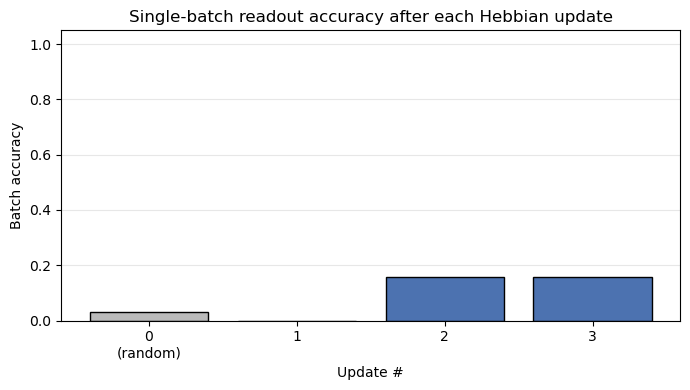

In [17]:
# ---- 1. Batch accuracy after each update ----
fig, ax = plt.subplots(figsize=(7, 4))
updates_range = list(range(len(batch_accuracies)))
ax.bar(updates_range, batch_accuracies, color=["#bbb"] + ["#4c72b0"] * N_UPDATES, edgecolor="black")
ax.set_xlabel("Update #")
ax.set_ylabel("Batch accuracy")
ax.set_title("Single-batch readout accuracy after each Hebbian update")
ax.set_xticks(updates_range)
ax.set_xticklabels([f"{i}\n{'(random)' if i==0 else ''}" for i in updates_range])
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_11892/2752122905.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


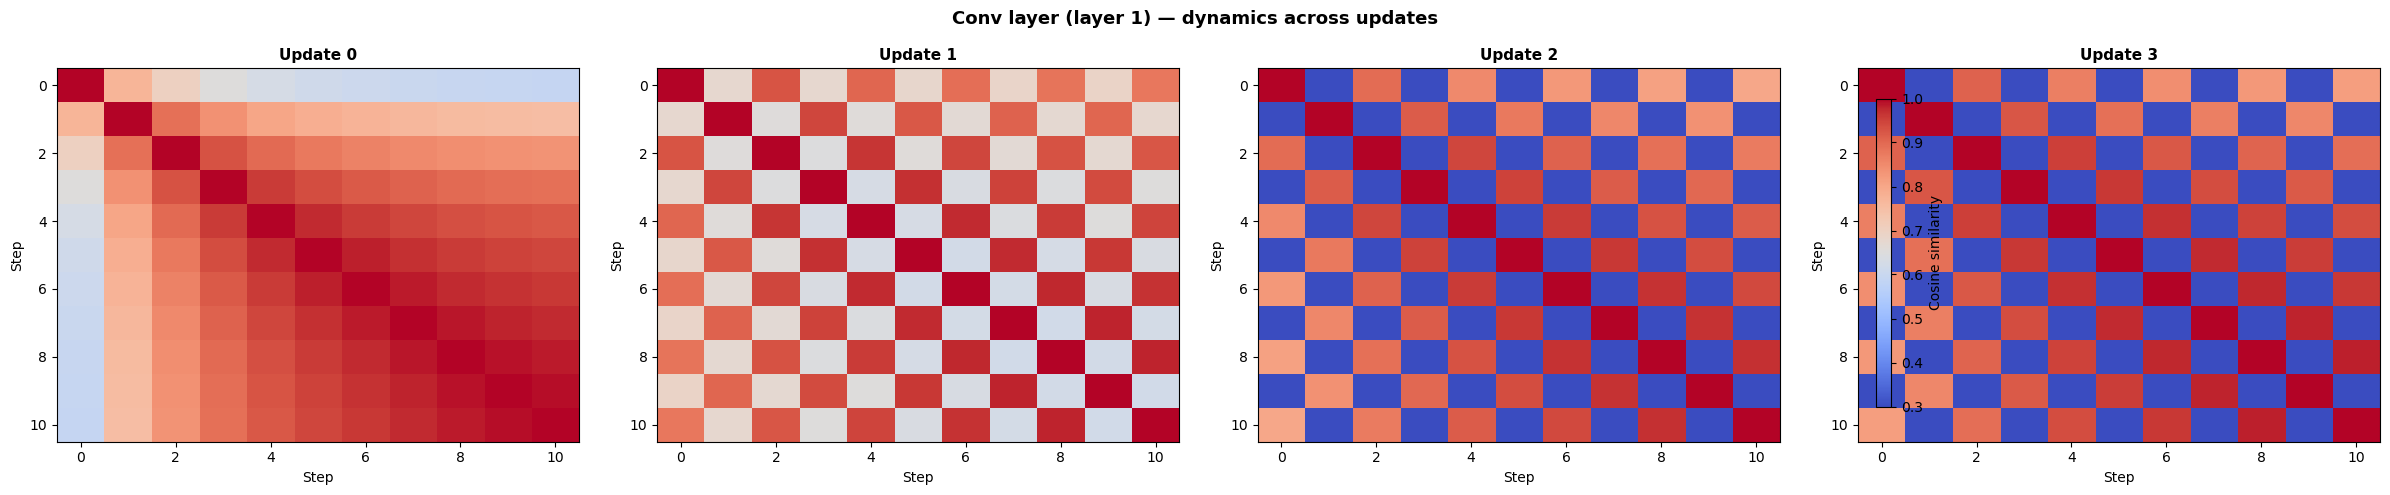

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_11892/2752122905.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


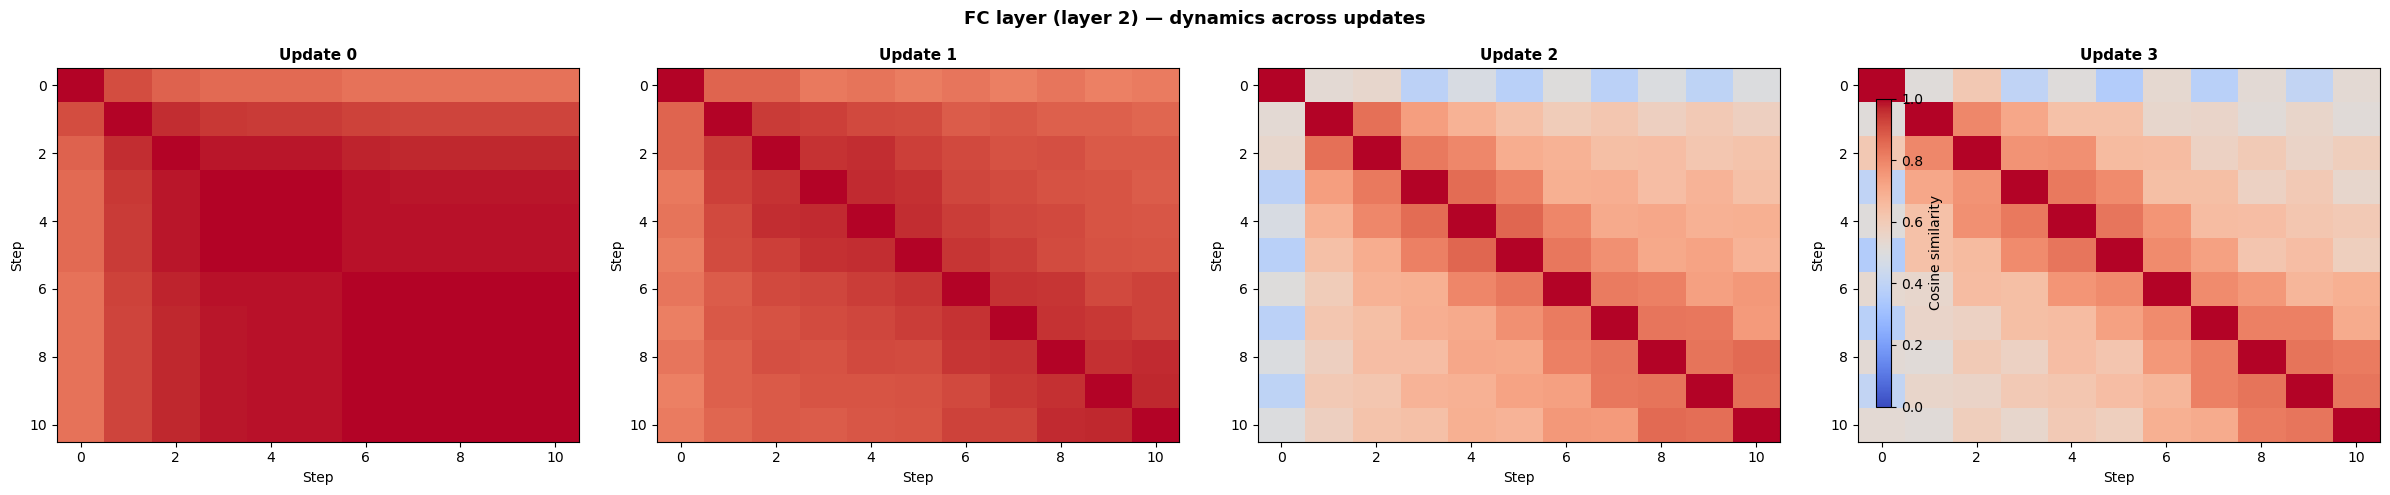

In [19]:
# ---- 2. Cosine similarity heatmaps: how dynamics change with updates ----
n_plots = min(len(probe_trajectories), 4)
updates_to_show = sorted(probe_trajectories.keys())[:n_plots]

# Conv layer (layer 1)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for idx, up in enumerate(updates_to_show):
    traj = probe_trajectories[up]
    cm = compute_cosine_similarity_matrix(traj, layer_idx=1)
    im = axes[idx].imshow(cm, cmap='coolwarm', aspect='auto', vmin=0.3, vmax=1)
    axes[idx].set_title(f"Update {up}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Step")
    axes[idx].set_ylabel("Step")

fig.colorbar(im, ax=axes, shrink=0.8, label="Cosine similarity")
fig.suptitle("Conv layer (layer 1) — dynamics across updates", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# FC layer (layer 2)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for idx, up in enumerate(updates_to_show):
    traj = probe_trajectories[up]
    cm = compute_cosine_similarity_matrix(traj, layer_idx=2)
    im = axes[idx].imshow(cm, cmap='coolwarm', aspect='auto', vmin=0.0, vmax=1)
    axes[idx].set_title(f"Update {up}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Step")
    axes[idx].set_ylabel("Step")

fig.colorbar(im, ax=axes, shrink=0.8, label="Cosine similarity")
fig.suptitle("FC layer (layer 2) — dynamics across updates", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

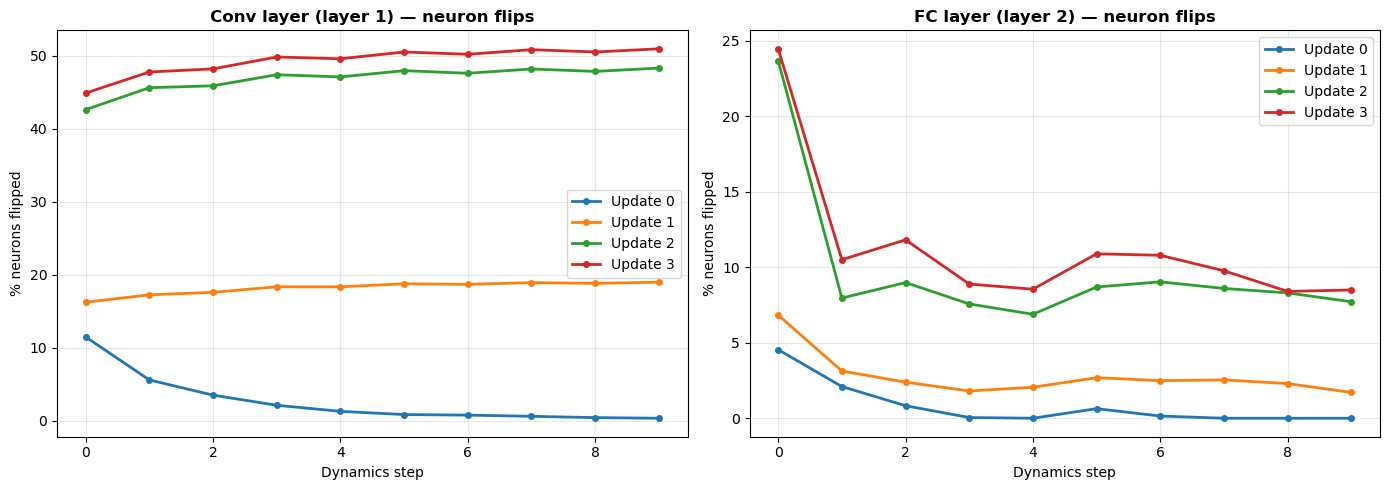

In [20]:
# ---- 3. Neuron flips across updates ----
def compute_neuron_flips(states_history, layer_idx=1, percentage=True):
    n_timesteps = len(states_history)
    flips = np.zeros(n_timesteps - 1)
    for t in range(n_timesteps - 1):
        s_t = states_history[t].states[layer_idx].reshape(states_history[t].states[layer_idx].shape[0], -1)
        s_t1 = states_history[t+1].states[layer_idx].reshape(states_history[t+1].states[layer_idx].shape[0], -1)
        n_neurons = s_t.shape[1]
        flip_counts = [np.sum(s_t[b] != s_t1[b]) for b in range(s_t.shape[0])]
        mean_flips = np.mean(flip_counts)
        flips[t] = (mean_flips / n_neurons * 100) if percentage else mean_flips
    return flips

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for up in sorted(probe_trajectories.keys()):
    flips = compute_neuron_flips(probe_trajectories[up], layer_idx=1, percentage=True)
    axes[0].plot(range(len(flips)), flips, 'o-', label=f"Update {up}", linewidth=2, markersize=4)

axes[0].set_xlabel("Dynamics step")
axes[0].set_ylabel("% neurons flipped")
axes[0].set_title("Conv layer (layer 1) — neuron flips", fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for up in sorted(probe_trajectories.keys()):
    flips = compute_neuron_flips(probe_trajectories[up], layer_idx=2, percentage=True)
    axes[1].plot(range(len(flips)), flips, 'o-', label=f"Update {up}", linewidth=2, markersize=4)

axes[1].set_xlabel("Dynamics step")
axes[1].set_ylabel("% neurons flipped")
axes[1].set_title("FC layer (layer 2) — neuron flips", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

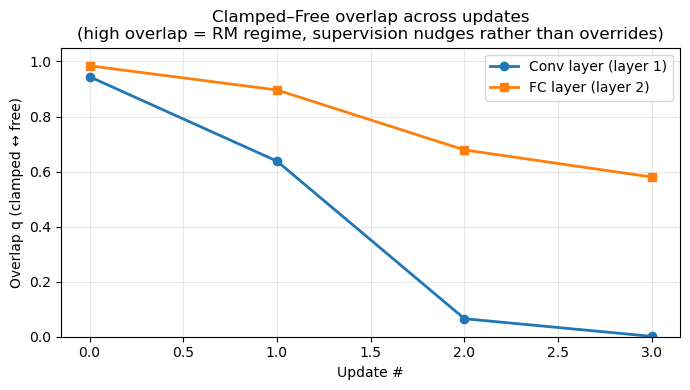

Overlap values:
  Update 0: conv=0.9447, fc=0.9844
  Update 1: conv=0.6380, fc=0.8965
  Update 2: conv=0.0655, fc=0.6787
  Update 3: conv=0.0013, fc=0.5801


In [21]:
# ---- 4. Clamped–Free overlap across updates ----
def compute_clamped_free_overlap(trajectory, layer_idx, n_warmup=1, n_clamped=5):
    clamped_end_idx = n_warmup + n_clamped - 1
    free_end_idx = len(trajectory) - 1
    
    s_clamped = trajectory[clamped_end_idx].states[layer_idx].reshape(
        trajectory[clamped_end_idx].states[layer_idx].shape[0], -1
    )
    s_free = trajectory[free_end_idx].states[layer_idx].reshape(
        trajectory[free_end_idx].states[layer_idx].shape[0], -1
    )
    
    N = s_clamped.shape[1]
    overlaps = np.sum(np.array(s_clamped) * np.array(s_free), axis=1) / N
    return float(np.mean(overlaps))

overlaps_conv = []
overlaps_fc = []
for up in sorted(probe_trajectories.keys()):
    traj = probe_trajectories[up]
    overlaps_conv.append(compute_clamped_free_overlap(traj, layer_idx=1, n_warmup=N_WARMUP, n_clamped=N_CLAMPED))
    overlaps_fc.append(compute_clamped_free_overlap(traj, layer_idx=2, n_warmup=N_WARMUP, n_clamped=N_CLAMPED))

fig, ax = plt.subplots(figsize=(7, 4))
updates_list = sorted(probe_trajectories.keys())
ax.plot(updates_list, overlaps_conv, 'o-', label="Conv layer (layer 1)", linewidth=2)
ax.plot(updates_list, overlaps_fc, 's-', label="FC layer (layer 2)", linewidth=2)
ax.set_xlabel("Update #")
ax.set_ylabel("Overlap q (clamped ↔ free)")
ax.set_title("Clamped–Free overlap across updates\n(high overlap = RM regime, supervision nudges rather than overrides)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Overlap values:")
for up, qc, qf in zip(updates_list, overlaps_conv, overlaps_fc):
    print(f"  Update {up}: conv={qc:.4f}, fc={qf:.4f}")

## Fast training loop — JIT-compiled with `DynamicalTrainer`

The single-batch analysis above uses Python-level for-loops (one `orchestrator.step()` call at a time), which is great for recording trajectories but **far too slow** for training on the full dataset.

`DynamicalTrainer` (the same class used in Tutorial 9) solves this by:
1. **`jax.lax.scan`** — fuses all dynamics steps (warmup + clamped + free) into a single compiled loop. No Python overhead per step.
2. **`equinox.filter_jit`** — JIT-compiles the entire train/eval step into one XLA kernel. The first batch triggers compilation (~30–60 s), but every subsequent batch runs at full speed.

This gives a **10–100× speedup** over the Python-loop approach.

In [22]:
from darnax.trainers.dynamical import DynamicalTrainer

# ============================================================
# Configuration
# ============================================================
N_EPOCHS_FAST = 3
LR_WIN   = 0.1
LR_JCONV = 0.05
LR_JFC   = 0.05
LR_WOUT  = 0.1

# ---- Build fresh model ----
key = jax.random.PRNGKey(0)
key, model_keys = jax.random.split(key)
keys_net = jax.random.split(model_keys, 5)

_input_to_hidden = Conv2D(
    in_channels=3, out_channels=N_CHANNELS, kernel_size=INPUT_KERNEL_SIZE,
    threshold=1.7, strength=1.0, key=keys_net[0], padding_mode='constant',
)
_recurrent_conv = Conv2DRecurrentDiscrete(
    channels=N_CHANNELS, kernel_size=RECUR_KERNEL_SIZE, groups=N_CHANNELS,
    j_d=0.9, threshold=1.7, padding_mode="constant",
    key=keys_net[1], lr=1.0, weight_decay=0.0,
)
_pooling_forward = GlobalMajorityPooling(strength=1.0, axis=(1, 2))
_unpooling_backward = GlobalUnpooling(strength=1.0, axis=(1, 2))
_recurrent = RecurrentDiscrete(
    features=N_CHANNELS, j_d=0.9, threshold=1.7, key=keys_net[2],
)
_wout = FullyConnected(
    in_features=N_CHANNELS, out_features=10,
    strength=1.0, threshold=1.7, key=keys_net[3],
)
_wback = FrozenRescaledFullyConnected(
    in_features=10, out_features=N_CHANNELS,
    strength=1.0, threshold=0.0, key=keys_net[4],
)

_layer_map = LayerMap.from_dict({
    1: {0: _input_to_hidden, 1: _recurrent_conv, 2: _unpooling_backward},
    2: {1: _pooling_forward, 2: _recurrent, 3: _wback},
    3: {2: _wout, 3: OutputLayer()},
})
orch_fast = SequentialOrchestrator(layers=_layer_map)

# ---- Build optimizer ----
params, _ = eqx.partition(orch_fast, eqx.is_inexact_array)
labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

def like(tree, value):
    return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

for (i, j), label in {(1,0): "w_in", (1,1): "j_conv", (2,2): "j_fc", (3,2): "w_out"}.items():
    labels = eqx.tree_at(
        lambda m, _i=i, _j=j: m.lmap[_i][_j], labels,
        replace=like(params.lmap[i][j], label),
    )

optimizer_fast = optax.multi_transform(
    {
        "default": optax.sgd(learning_rate=0.0),
        "w_in":    optax.sgd(learning_rate=LR_WIN),
        "j_conv":  optax.sgd(learning_rate=LR_JCONV),
        "j_fc":    optax.sgd(learning_rate=LR_JFC),
        "w_out":   optax.sgd(learning_rate=LR_WOUT),
    },
    labels,
)
opt_state_fast = optimizer_fast.init(eqx.filter(orch_fast, eqx.is_inexact_array))

# ---- Build state template + trainer ----
state_template = SequentialState(
    [(32, 32, 3), (32, 32, N_CHANNELS), (N_CHANNELS,), (10,)]
)

trainer = DynamicalTrainer(
    orchestrator=orch_fast,
    state=state_template,
    optimizer=optimizer_fast,
    optimizer_state=opt_state_fast,
    warmup_n_iter=1,
    train_clamped_n_iter=5,
    train_free_n_iter=5,
    eval_n_iter=10,
)

# ============================================================
# Training loop  (JIT-compiled — first batch is slow, rest are fast)
# ============================================================
from time import perf_counter

history_fast = {"train_acc": [], "test_acc": []}

for epoch in range(N_EPOCHS_FAST + 1):
    t0 = perf_counter()

    # ---- Train (skip epoch 0 = baseline) ----
    if epoch != 0:
        for xb, yb in data:
            if xb.ndim == 2:
                xb = xb.reshape(xb.shape[0], 32, 32, 3)
            xb = (xb - xb.mean()) / (xb.std() + 1e-8)
            key = trainer.train_step(xb, yb, key)

    # ---- Evaluate on test split ----
    accs_test = []
    for xb, yb in data.iter_test():
        if xb.ndim == 2:
            xb = xb.reshape(xb.shape[0], 32, 32, 3)
        xb = (xb - xb.mean()) / (xb.std() + 1e-8)
        key, metrics = trainer.eval_step(xb, yb, key)
        accs_test.append(float(metrics["accuracy"]))

    test_acc = float(jnp.mean(jnp.array(accs_test)))

    # ---- Evaluate on train split ----
    accs_train = []
    for xb, yb in data:
        if xb.ndim == 2:
            xb = xb.reshape(xb.shape[0], 32, 32, 3)
        xb = (xb - xb.mean()) / (xb.std() + 1e-8)
        key, metrics = trainer.eval_step(xb, yb, key)
        accs_train.append(float(metrics["accuracy"]))

    train_acc = float(jnp.mean(jnp.array(accs_train)))

    history_fast["train_acc"].append(train_acc)
    history_fast["test_acc"].append(test_acc)

    elapsed = perf_counter() - t0
    print(f"Epoch {epoch:02d} | train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | {elapsed:.1f}s")

print("\nTraining complete!")

Epoch 00 | train_acc=0.0749 | test_acc=0.0787 | 864.2s


KeyboardInterrupt: 

In [ ]:
# ---- Accuracy curves (fast training) ----
fig, ax = plt.subplots(figsize=(7, 4))
epochs_range = list(range(len(history_fast["train_acc"])))
ax.plot(epochs_range, history_fast["train_acc"], 'o-', label="Train")
ax.plot(epochs_range, history_fast["test_acc"], 's-', label="Test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Conv model (DynamicalTrainer): accuracy over training")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()